In [ ]:
import cmocean
import warnings

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from pathlib import Path

import hfplot.figure.figure as hffig
import pycompo.core.utils as pcutil

warnings.filterwarnings(action='ignore')

def get_bin_centers(bin_edges: np.ndarray) -> np.ndarray:
    return (bin_edges[:-1] + bin_edges[1:]) / 2


def calc_tau_adv(length_scale_km, velocity_scale_kmh):
    return length_scale_km / velocity_scale_kmh

def calc_tau_mix(blh=500, K_t=50):
    return (blh**2/K_t)/3600

def calc_L_mix_km(bg_sfcwind, blh=500, K_t=50):
    return bg_sfcwind * calc_tau_mix(blh, K_t)*3.6

def calc_tau_coriolis(lat):
    omega = 7.2921e-5  # Earth's angular velocity in radians per second
    f = 2 * omega * np.sin(np.radians(lat))  # Coriolis parameter
    return 1/f/3600  # Convert to hours

def calc_L_coriolis_km(bg_sfcwind, lat):
    return bg_sfcwind * calc_tau_coriolis(lat)*3.6


# ------------------------------------------------------------------------------
# read in configuration file
featprops = {}
for ana_idf in ["ngc5004_opv4_w0", "ngc5004_opv4_w1", "ngc5004_opv4_w1_p"]:
    config_file = f"/home/m/m300738/libs/pycompo/config/settings_{ana_idf}.yaml"
    config = pcutil.read_yaml_config(config_file)
    analysis_times = pcutil.create_analysis_times(config)

    # load feature_props
    inpath = Path(f"{config['data']['outpath']}/{ana_idf}/")
    infile = Path(f"{ana_idf}_feature_props_rainbelt_all.nc")
    featprops[ana_idf] = xr.open_dataset(str(inpath/infile))
    featprops[ana_idf]['diameter_km'] = featprops[ana_idf]['radius_km'] * 2
    featprops[ana_idf]['tau_adv'] = calc_tau_adv(
        featprops[ana_idf]['diameter_km'], featprops[ana_idf]['bg_sfcwind']*3.6,
        )
    featprops[ana_idf]['lengthscale'] = calc_L_mix_km(
        featprops[ana_idf]['bg_sfcwind'], blh=500, K_t=50,
        )
    
exp ='ngc5004_opv4_w1'

Amount of SST features in rainbelt for ngc5004_opv4_w0: 60270
Amount of SST features in rainbelt for ngc5004_opv4_w1: 60270
Amount of SST features in rainbelt for ngc5004_opv4_w1_p: 57425


### Plotting

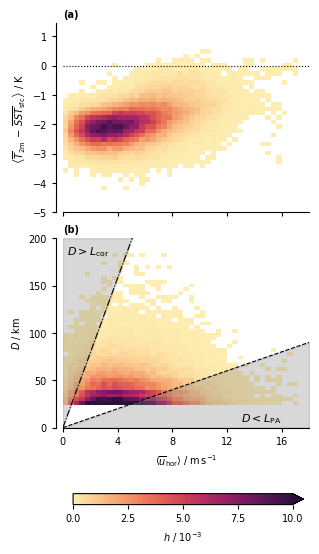

In [ ]:
import matplotlib.pyplot as plt
import hfplot.figure.figure as hffig

exp ='ngc5004_opv4_w1'
stats_list = [('bg_sfcwind', 'bg_tas-ts'), ('bg_sfcwind', 'diameter_km')]

bins = {
    'bg_tas-ts': np.arange(-5, 1.6, 0.15),
    'bg_sfcwind': np.arange(0, 17.6, 0.4),
    'diameter_km': np.arange(20, 196, 4),
}
labels = {
    'bg_tas-ts': '$\left\langle \overline{T}_{\mathrm{2m}}\,-\,\overline{SST}_{\mathrm{sfc}}\\right\\rangle$ / K',
    'bg_sfcwind': '$\langle \overline{u}_{\mathrm{hor}}\\rangle$ / m$\,$s$^{-1}$',
    'diameter_km': '$D$ / km',
}

# ------------------------------------------------------------------------------
# Plotting
fig, axs = hffig.init_subfig(
    style=('ams', 'one_column'), asprat=(3.2, 5.5), nrow=2, ncol=1, sharex=True, sharey=False,
    offset_x=0, offset_y=5,
    )

mappable = None

for i, var in enumerate(stats_list):
    # calc 2d histogram
    counts, bins_x, bins_y = np.histogram2d(
        featprops[exp][var[0]].values, featprops[exp][var[1]].values,
        bins=(bins[var[0]], bins[var[1]])
    )
    rel_freq = counts/counts.sum() * 10**3

    plot_data = np.ma.masked_equal(rel_freq, 0)
    pl2 = axs.ravel()[i].pcolormesh(
        get_bin_centers(bins_x), get_bin_centers(bins_y), plot_data.transpose(),
        cmap=cmocean.cm.matter, vmin=0, vmax=10,
        )
    if mappable is None:
        mappable = pl2
    axs.ravel()[i].set_ylabel(labels[var[1]])
    if i==1: axs.ravel()[i].set_xlabel(labels[var[0]])

axs.ravel()[0].axhline(y=0, ls=':', color='k', lw=0.8)

# Plot the shaded area
y_shade = np.linspace(0, 200, 300)
x_shade = y_shade / (calc_tau_coriolis(10) * 3.6)
axs.ravel()[1].fill_betweenx(
    y_shade, 0, x_shade, color='gray', alpha=0.3, zorder=1,
    )
x_mix = np.linspace(0, 18, 300)
y_mix = calc_L_mix_km(x_mix)
axs.ravel()[1].fill_between(
    x_mix, 0, y_mix, color='gray', alpha=0.3, zorder=1,
    )
axs.ravel()[1].text(
    0.3, 183, '$D > L_{\mathrm{cor}}$',
    color='k', fontsize=8, fontweight='bold', zorder=4,
    bbox=dict(facecolor='none', alpha=0.75, edgecolor='none', pad=2),
    )
axs.ravel()[1].text(
    13.0, 7, '$D < L_{\mathrm{PA}}$',
    color='k', fontsize=8, fontweight='bold', zorder=4,
    bbox=dict(facecolor='none', alpha=0.75, edgecolor='none', pad=2),
    )

axs.ravel()[1].plot(
    [0, 18], [calc_L_mix_km(0), calc_L_mix_km(18)],
    ls='--', color='k', lw=0.8,
    )
axs.ravel()[1].plot(
    [0, 18], [calc_L_coriolis_km(0, lat=10), calc_L_coriolis_km(18, lat=10)],
    ls='-.', color='k', lw=0.8,
)

axs.ravel()[1].set_xlim(0, 18)
axs.ravel()[1].set_ylim(0, 200)
axs.ravel()[1].set_xticks([0, 4, 8, 12, 16])
axs.ravel()[1].set_yticks([0, 50, 100, 150, 200])

cbar_ax = fig.add_axes([0.23, 0.08, 0.72, 0.02])
fig.colorbar(
    pl2, cax=cbar_ax, orientation='horizontal', extend='max',
    label='$h$ / $10^{-3}$', ticks=[0, 2.5, 5, 7.5, 10],
    )

plt.tight_layout()
fig.subplots_adjust(bottom=0.22)
outpath = Path(f'/home/m/m300738/project_TRR181L4/plots/paper/')
outpath.mkdir(parents=True, exist_ok=True)
outfile = Path('figure06.png')
plt.savefig(str(outpath/outfile), dpi=600)
plt.show()